### $\Lambda$-CDM Small Curvature Constant Notebook
Finally, let's see what happens if we do $\Lambda$-CDM, but introduce a very, very small curvature on the order of $\Omega_k = 0.005$.

In [25]:
%load_ext autoreload
%autoreload 2

import time
import os
import matplotlib.pyplot as plt
import random

from utils import *
from tqdm import tqdm
from functools import partial
from matplotlib.animation import FuncAnimation
from IPython.display import Video

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# some statements to make the figures look nicer 
%config InlineBackend.figure_format = 'retina'

plt.rcParams.update({
    'axes.linewidth': 2,
    'ytick.major.width': 2,
    'ytick.minor.width': 2,
    'xtick.major.width': 2,
    'xtick.minor.width': 2,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'axes.labelsize': 16,
    'legend.fontsize': 16,
    'axes.titlesize': 17,
    'font.family': 'serif',
    'figure.figsize': (10, 6),
})

In [27]:
# Caching directory 
DATA_DIR = os.path.expanduser("data")
CACHE_DIR = os.path.join(DATA_DIR, "lcdm-curvature-analysis")
os.makedirs(CACHE_DIR, exist_ok=True)

# Making sure no random variance
random.seed(42)

In [28]:
# Lambda-CDM cosmology with Omega_Lambda = 0.1 (small test)
params = CosmologicalParameters(H0=1, Omega_m=0.3, Omega_Lambda=0.6995)

# Simulation parameters for cosmological run
Ng_cosmo = 128
Np_cosmo = 128
L_cosmo = 200.0       # Mpc/h (comoving box size)
z_init = 49.0
a_init_cosmo = 1.0 / (1.0 + z_init)

In [29]:
# Creating class cosmology
cosmo = create_cosmo_instance(
    h=0.7,
    omega_b=0.02237,
    omega_cdm=0.1200
)
h_class = cosmo.h()
print(f"CLASS cosmology: Omega_m = {cosmo.Omega_m():.4f}, "
      f"h = {h_class:.3f}, sigma8 = {cosmo.sigma8():.4f}")

CLASS cosmology: Omega_m = 0.2906, h = 0.700, sigma8 = 0.8300


In [30]:
# Precompute Green's function for the cosmological grid
green_cx, green_cy, green_cz = make_green_function(Ng_cosmo, L_cosmo)

# Run from z=49 to z=0 (a=0.02 to a=1)
a_final_cosmo = 1.0
n_steps_cosmo = 100

print(f"Running {Np_cosmo}^3 simulation: a = {a_init_cosmo:.4f} → {a_final_cosmo}")
print(f"  {n_steps_cosmo} steps, Ng = {Ng_cosmo}, L = {L_cosmo} Mpc/h")

Running 128^3 simulation: a = 0.0200 → 1.0
  100 steps, Ng = 128, L = 200.0 Mpc/h


In [31]:
# Defining P(k) using the new cosmo parameter
p_k = partial(pk_of_k, cosmo=cosmo)
pos_cosmo, mom_cosmo, q_cosmo, _ = make_cosmo_ic(
    Np_cosmo, Ng_cosmo, L_cosmo, p_k, a_init_cosmo, params=params
)
print(f"Particles: {pos_cosmo.shape[0]:,}")
print(f"Initial rms displacement: {np.std(np.array(pos_cosmo - q_cosmo)):.4f} Mpc/h")

Particles: 2,097,152
Initial rms displacement: 0.1883 Mpc/h


In [32]:
pos_cosmo_final, mom_cosmo_final = run_simulation(
    pos_cosmo, mom_cosmo, a_init_cosmo, a_final_cosmo, n_steps_cosmo,
    green_cx, green_cy, green_cz, Ng_cosmo, L_cosmo, params=params
)
print("Done!")

Done!


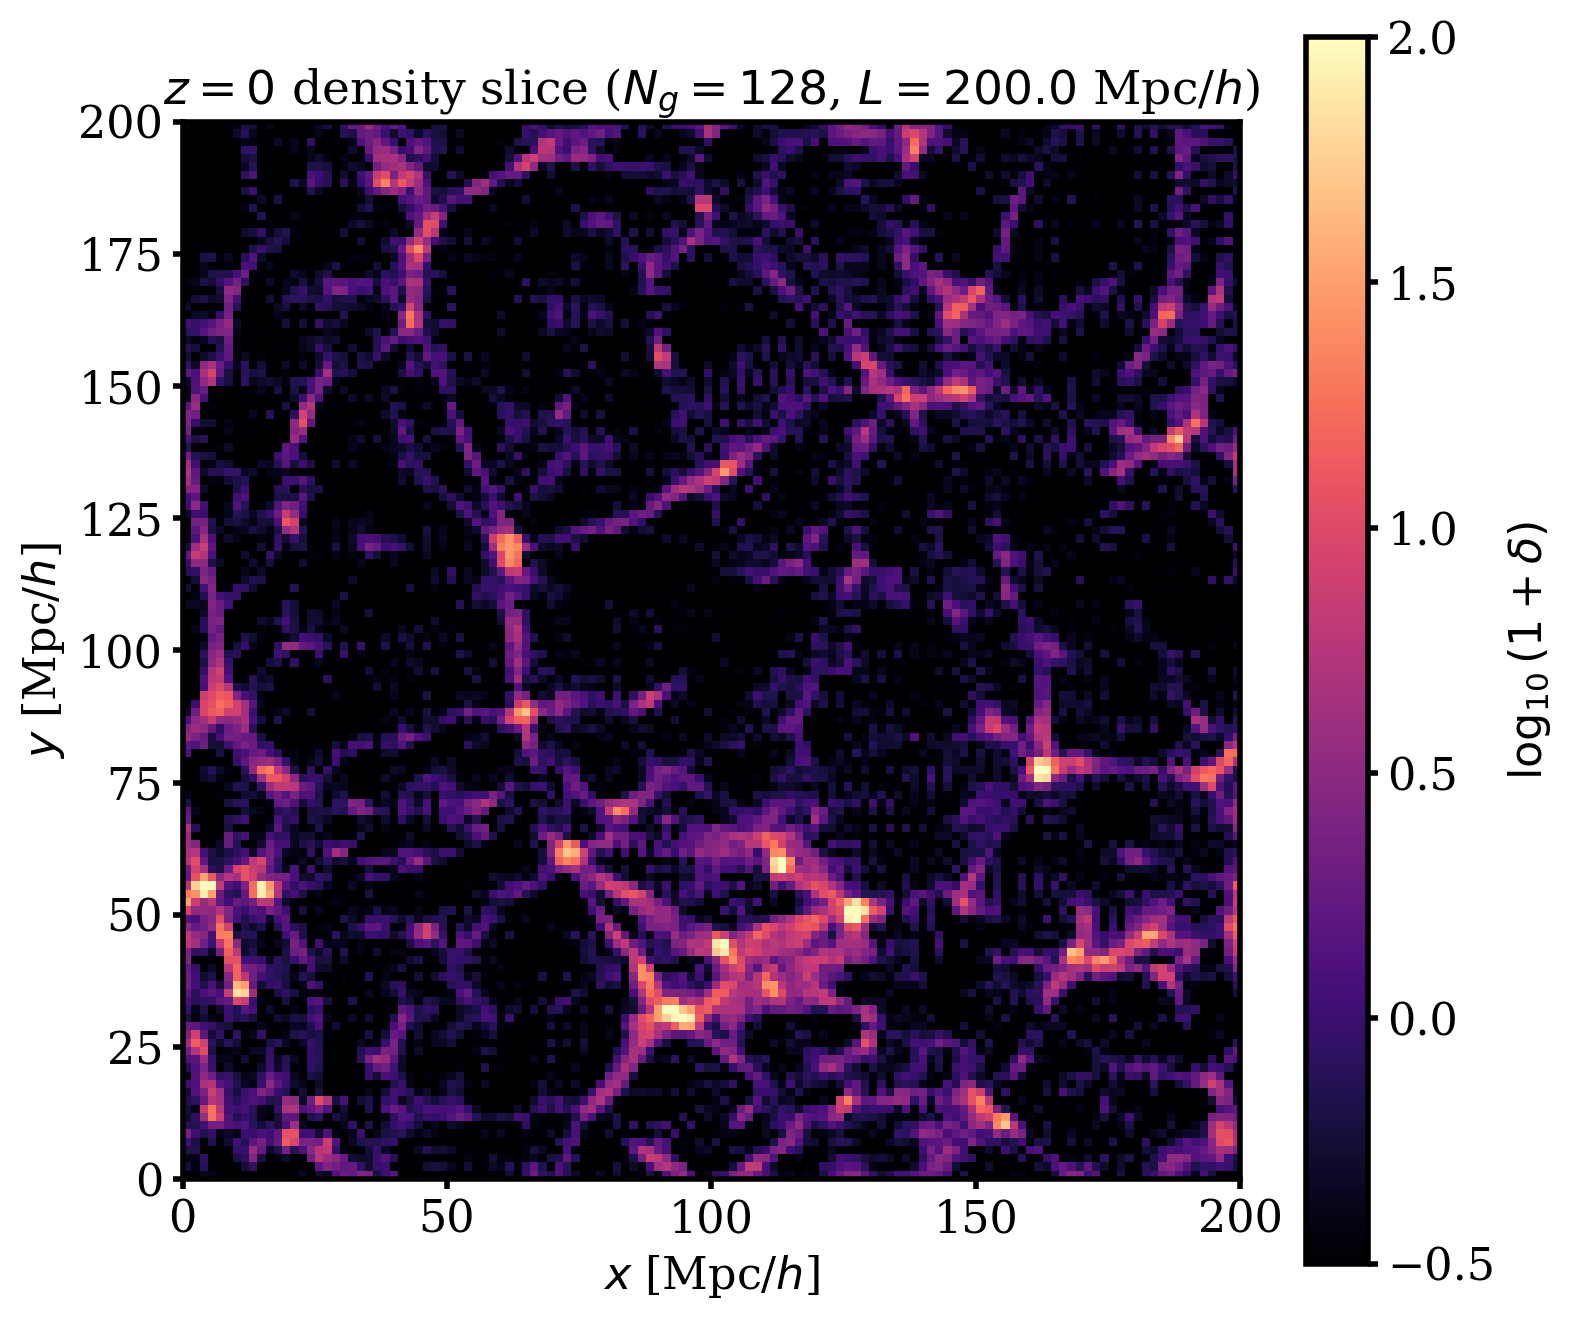

Density field statistics at z=0:
  min(delta) = -1.00
  max(delta) = 762.6
  rms(delta) = 5.06


In [33]:
# Deposit final positions onto grid
rho_final = cic_deposit(pos_cosmo_final, Ng_cosmo, L_cosmo)
rho_bar = Np_cosmo**3 / Ng_cosmo**3
delta_final = rho_final / rho_bar - 1.0

# Take a thin slice (single grid plane)
slice_z = Ng_cosmo // 2

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

im = ax.imshow(
    np.log10(np.maximum(1 + np.array(delta_final[:, :, slice_z]), 1e-6)).T,
    origin='lower',
    extent=[0, L_cosmo, 0, L_cosmo],
    cmap='magma',
    vmin=-0.5,
    vmax=2.0
)
ax.set_xlabel('$x$ [Mpc/$h$]')
ax.set_ylabel('$y$ [Mpc/$h$]')
ax.set_title(f'$z = 0$ density slice ($N_g = {Ng_cosmo}$, '
             f'$L = {L_cosmo}$ Mpc/$h$)')
plt.colorbar(im, ax=ax, label='$\\log_{10}(1 + \\delta)$', shrink=0.8)
plt.tight_layout()
plt.show()

# Statistics
print(f"Density field statistics at z=0:")
print(f"  min(delta) = {delta_final.min():.2f}")
print(f"  max(delta) = {delta_final.max():.1f}")
print(f"  rms(delta) = {jnp.std(delta_final):.2f}")

In [34]:
# Scale factors for the movie frames (log-spaced)
n_frames = 50
a_frames = np.exp(np.linspace(np.log(a_init_cosmo), np.log(a_final_cosmo), n_frames))

# Run simulation to each epoch and store density slices
slices = []
for a_snap in tqdm(a_frames):
    n_steps_snap = max(10, int(100 * (a_snap - a_init_cosmo) / (a_final_cosmo - a_init_cosmo)))
    pos_s, _ = run_simulation(
        pos_cosmo, mom_cosmo, a_init_cosmo, a_snap, n_steps_snap,
        green_cx, green_cy, green_cz, Ng_cosmo, L_cosmo, params=params
    )
    rho_s = cic_deposit(pos_s, Ng_cosmo, L_cosmo)
    delta_s = rho_s / rho_bar - 1.0
    slices.append(
        np.log10(np.maximum(1 + np.array(delta_s[:, :, slice_z]), 1e-6)).T
    )

# Build animation
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
im = ax.imshow(slices[0], origin='lower',
               extent=[0, L_cosmo, 0, L_cosmo],
               cmap='magma', vmin=-0.5, vmax=2.0)
ax.set_xlabel('$x$ [Mpc/$h$]')
ax.set_ylabel('$y$ [Mpc/$h$]')
title = ax.set_title(f'$z = {1/a_frames[0] - 1:.1f}$')
fig.colorbar(im, ax=ax, label='$\\log_{10}(1 + \\delta)$', shrink=0.8)
fig.tight_layout()

def update(frame):
    im.set_data(slices[frame])
    z_val = 1/a_frames[frame] - 1
    title.set_text(f'$z = {z_val:.1f}$')
    return [im, title]

anim = FuncAnimation(fig, update, frames=n_frames, interval=150, blit=True)

# Save as MP4
movie_path = f'{CACHE_DIR}/cosmic_web_evolution.mp4'
anim.save(movie_path, writer='ffmpeg', dpi=120)
plt.close(fig)

Video(movie_path, embed=True, html_attributes='controls loop autoplay muted width="700"')

100%|██████████| 50/50 [05:09<00:00,  6.19s/it]


We test the convergence of our models using the code from Lecture 20, adapted to use our model.

In [35]:
# Simulation parameters
Ng = 64          # grid cells per dimension
Np = 64          # particles per dimension (one particle per cell)
L = 1.0          # box size (code units)
params = CosmologicalParameters(H0=1, Omega_m=0.3, Omega_Lambda=0.6995)

# Precompute Green's function for this grid
green_x, green_y, green_z = make_green_function(Ng, L)

# Quick sanity check: uniform grid should give constant density
pos_test = make_uniform_grid(Np, L)
rho_test = cic_deposit(pos_test, Ng, L)
print(f"Sanity check: {Np}^3 = {Np**3} particles on {Ng}^3 grid")
print(f"  Density: min={rho_test.min():.4f}, max={rho_test.max():.4f} "
      f"(expected {(Np/Ng)**3:.4f})")

# Zel'dovich test parameters
n_mode = 2          # mode number (2 full wavelengths across the box)
A = 0.5             # initial amplitude (shell crossing at a = 1/A = 2)
k_mode = 2 * jnp.pi * n_mode / L

# Initial scale factor and final (before shell crossing)
a_init = 0.1
a_final = 1.5       # a_final * A = 0.75, before shell crossing at a=2

# Number of timesteps
n_steps = 100

print(f"\nMode: n={n_mode}, k={k_mode:.4f}")
print(f"Amplitude: A={A}")
print(f"Shell crossing at a = {1/A:.1f}")
print(f"Running from a={a_init} to a={a_final} ({n_steps} steps)")
print(f"Final displacement amplitude: a*A/k = {a_final * A / k_mode:.4f} "
      f"(in units of L)")

Sanity check: 64^3 = 262144 particles on 64^3 grid
  Density: min=1.0000, max=1.0000 (expected 1.0000)

Mode: n=2, k=12.5664
Amplitude: A=0.5
Shell crossing at a = 2.0
Running from a=0.1 to a=1.5 (100 steps)
Final displacement amplitude: a*A/k = 0.0597 (in units of L)


In [36]:
# Run to final time
pos_init, mom_init, q_grid = make_zeldovich_ic(Np, L, n_mode, A, a_init, params=params)

pos_final, mom_final = run_simulation(
    pos_init, mom_init, a_init, a_final, n_steps,
    green_x, green_y, green_z, Ng, L, params=params
)

# Zel'dovich prediction at final time
pos_exact, mom_exact = zeldovich_prediction(q_grid, n_mode, A, a_final, L, params=params)

# --- Helpers for visualization ---

# Extract 1D slice: particles along the x-axis with fixed q_y, q_z.
# With indexing='ij', stride by Np^2 to vary x at fixed y,z.
slice_idx = jnp.arange(0, Np**3, Np**2)
q_x = q_grid[slice_idx, 0]
sort_idx = jnp.argsort(q_x)
q_x_sorted = q_x[sort_idx]

def displacement(pos, q, L):
    """x-displacement from grid, with periodic unwrapping."""
    dx = pos[:, 0] - q[:, 0]
    dx = dx - L * jnp.round(dx / L)
    return dx

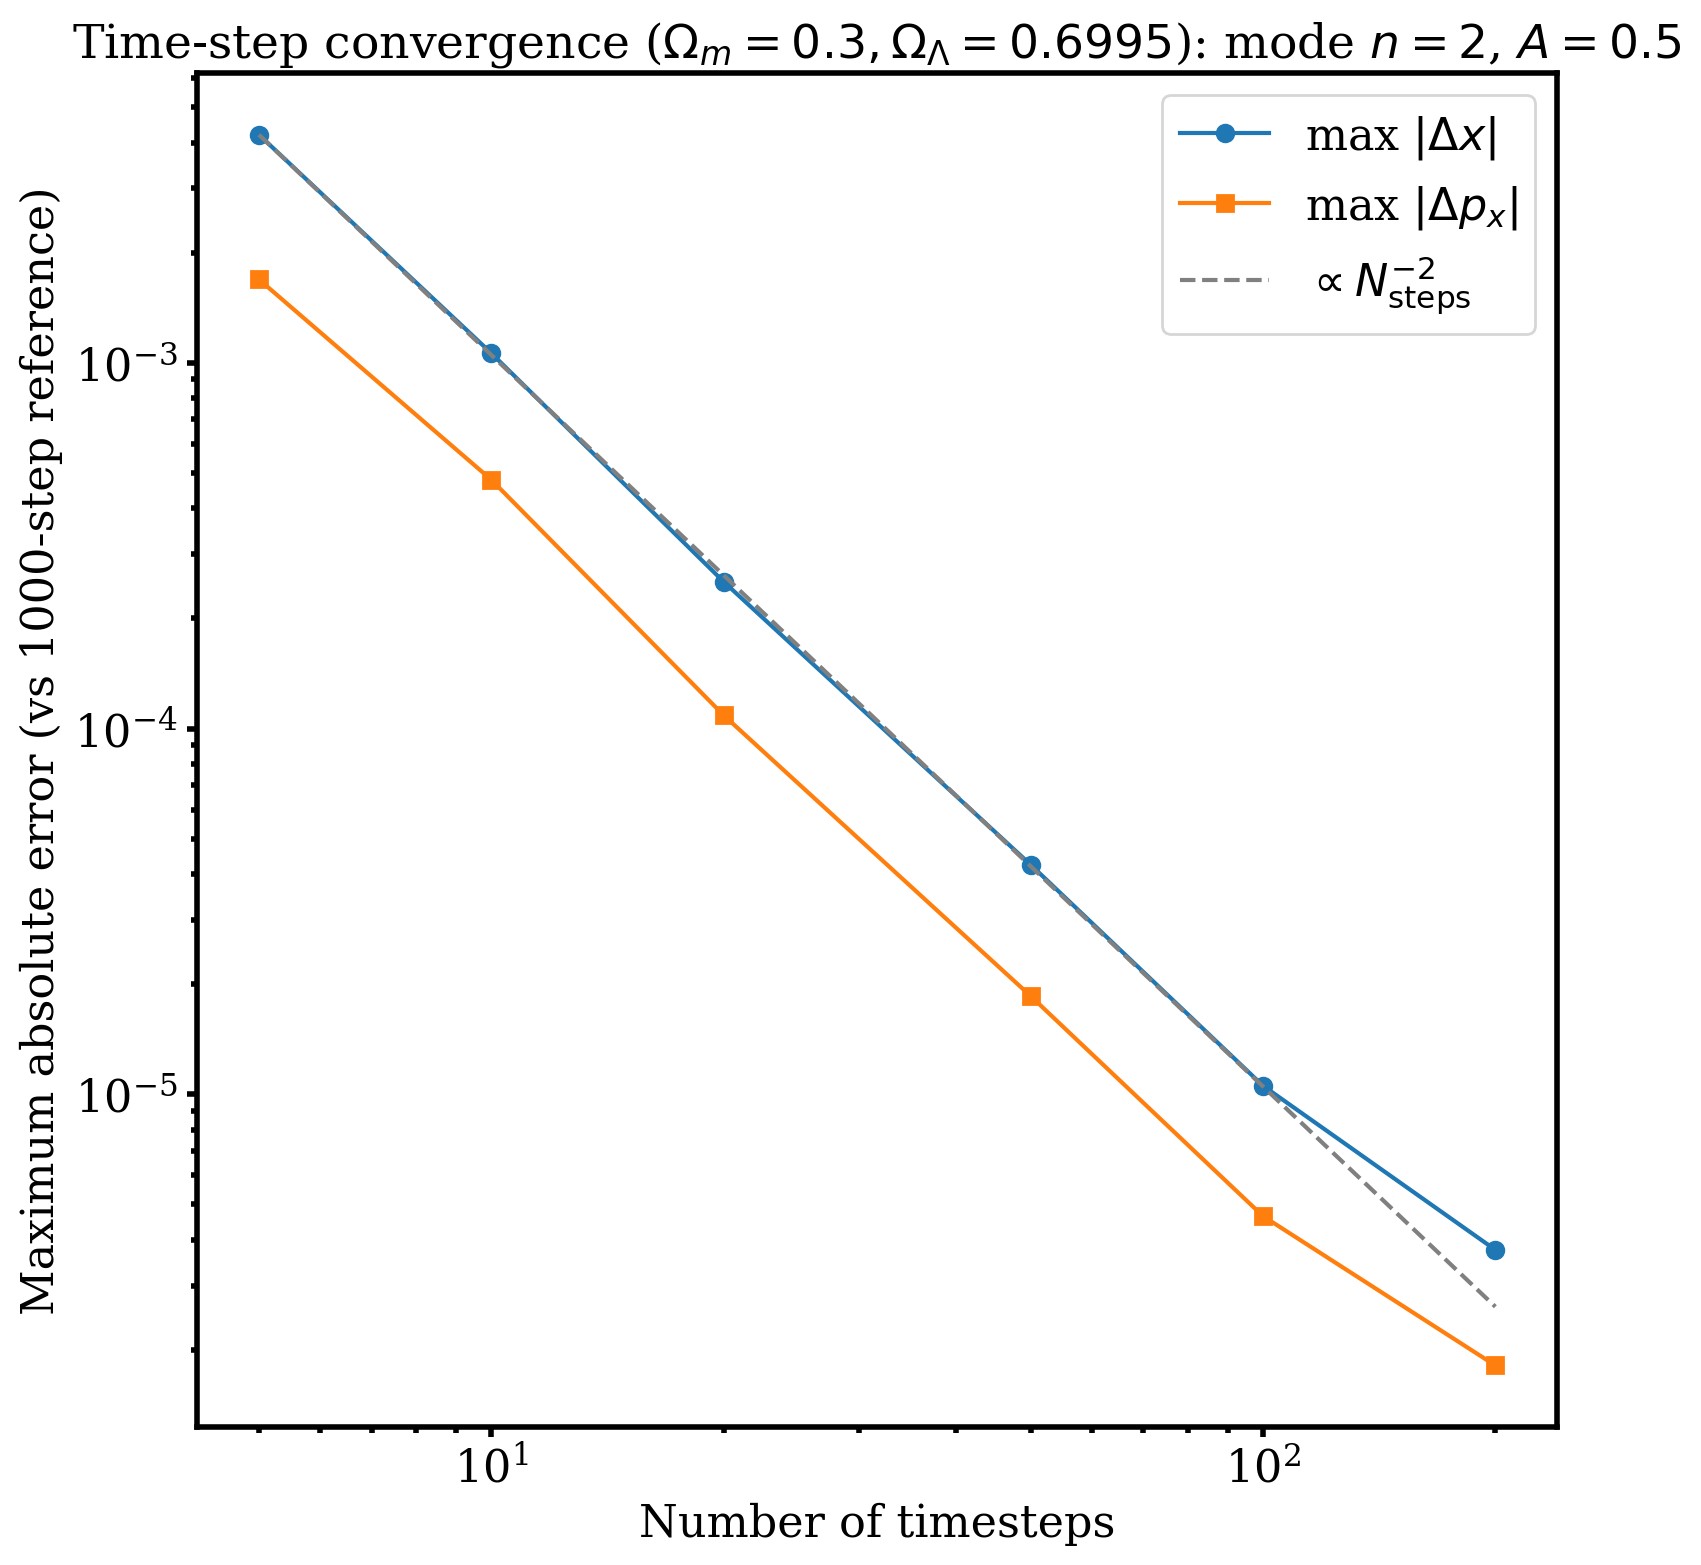

In [37]:
# High-resolution reference
pos_ref, mom_ref = run_simulation(
    pos_init, mom_init, a_init, a_final, 1000,
    green_x, green_y, green_z, Ng, L, params=params
)
dx_ref = displacement(pos_ref, q_grid, L)[slice_idx][sort_idx]
px_ref = mom_ref[slice_idx, 0][sort_idx]

step_counts = [5, 10, 20, 50, 100, 200]
dx_errors = []
px_errors = []

for ns in step_counts:
    pos_f, mom_f = run_simulation(
        pos_init, mom_init, a_init, a_final, ns,
        green_x, green_y, green_z, Ng, L, params=params
    )
    dx_s = displacement(pos_f, q_grid, L)[slice_idx][sort_idx]
    px_s = mom_f[slice_idx, 0][sort_idx]

    dx_errors.append(float(jnp.max(jnp.abs(dx_s - dx_ref))))
    px_errors.append(float(jnp.max(jnp.abs(px_s - px_ref))))

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.loglog(step_counts, dx_errors, 'o-', color='C0', label='max $|\\Delta x|$')
ax.loglog(step_counts, px_errors, 's-', color='C1', label='max $|\\Delta p_x|$')

# Reference line: N^{-2}
ns_ref = np.array(step_counts, dtype=float)
ax.loglog(ns_ref, dx_errors[0] * (ns_ref[0] / ns_ref)**2, '--',
          color='0.5', label='$\\propto N_{\\mathrm{steps}}^{-2}$')

ax.set_xlabel('Number of timesteps')
ax.set_ylabel('Maximum absolute error (vs 1000-step reference)')
ax.legend()
ax.set_title(f'Time-step convergence ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$): mode $n={n_mode}$, $A={A}$')
plt.tight_layout()
plt.savefig(f"tc_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()

Ng=Np= 32: max |Δx| = 4.77e-03, max |Δp| = 2.94e-03
Ng=Np= 64: max |Δx| = 2.24e-03, max |Δp| = 1.30e-03
Ng=Np=128: max |Δx| = 1.10e-03, max |Δp| = 6.30e-04


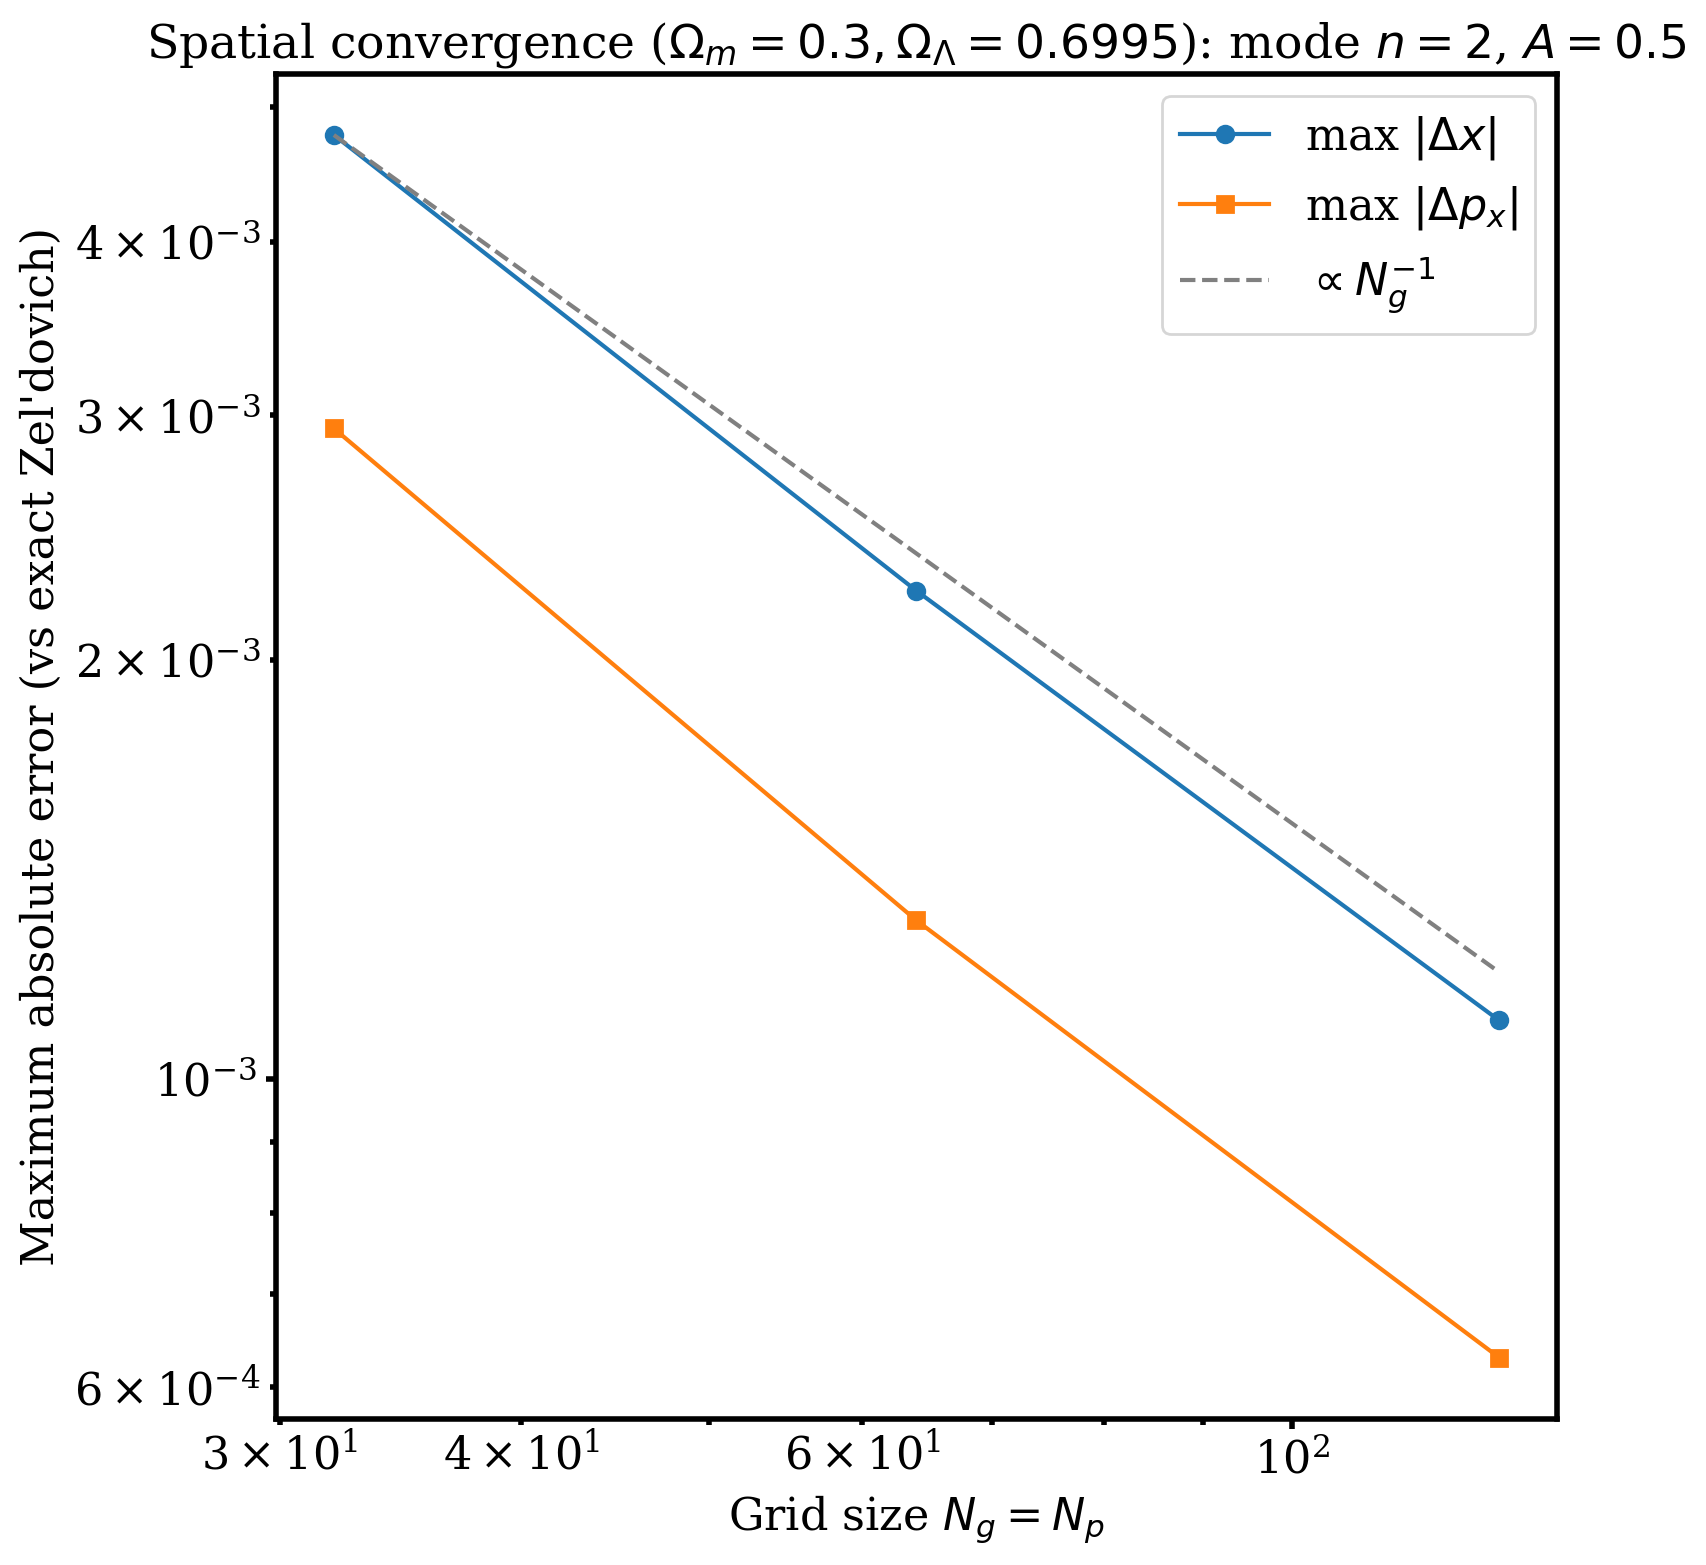

In [38]:
grid_sizes = [32, 64, 128]
n_steps_hires = 500  # enough steps to make time-step error negligible

dx_spatial_errors = []
px_spatial_errors = []

for N in grid_sizes:
    # Set up at this resolution
    green_xi, green_yi, green_zi = make_green_function(N, L)
    pos_i, mom_i, q_i = make_zeldovich_ic(N, L, n_mode, A, a_init, params=params)
    slice_i = jnp.arange(0, N**3, N**2)

    # Run simulation
    pos_f, mom_f = run_simulation(
        pos_i, mom_i, a_init, a_final, n_steps_hires,
        green_xi, green_yi, green_zi, N, L, params=params
    )

    # Exact solution
    pos_e, mom_e = zeldovich_prediction(q_i, n_mode, A, a_final, L, params=params)

    # Errors on the 1D slice
    q_xi = q_i[slice_i, 0]
    sort_i = jnp.argsort(q_xi)

    dx_f = displacement(pos_f, q_i, L)[slice_i][sort_i]
    dx_e = displacement(pos_e, q_i, L)[slice_i][sort_i]
    px_f = mom_f[slice_i, 0][sort_i]
    px_e = mom_e[slice_i, 0][sort_i]

    dx_spatial_errors.append(float(jnp.max(jnp.abs(dx_f - dx_e))))
    px_spatial_errors.append(float(jnp.max(jnp.abs(px_f - px_e))))

    print(f"Ng=Np={N:3d}: max |Δx| = {dx_spatial_errors[-1]:.2e}, "
          f"max |Δp| = {px_spatial_errors[-1]:.2e}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.loglog(grid_sizes, dx_spatial_errors, 'o-', color='C0',
          label='max $|\\Delta x|$')
ax.loglog(grid_sizes, px_spatial_errors, 's-', color='C1',
          label='max $|\\Delta p_x|$')

# Reference line: N^{-1}
ns_ref = np.array(grid_sizes, dtype=float)
ax.loglog(ns_ref, dx_spatial_errors[0] * (ns_ref[0] / ns_ref)**1, '--',
          color='0.5', label='$\\propto N_g^{-1}$')

ax.set_xlabel('Grid size $N_g = N_p$')
ax.set_ylabel('Maximum absolute error (vs exact Zel\'dovich)')
ax.legend()
ax.set_title(f'Spatial convergence ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$): mode $n={n_mode}$, $A={A}$')
plt.tight_layout()
plt.savefig(f"sc_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()

Now we use the code from Lecture 21.

In [39]:
# Simulation parameters
Ng = 256             # grid cells per dimension
Np = 256             # particles per dimension (= Ng for this run)
L = 500.0            # box size in Mpc/h
Omega_m = 0.3        # Lambda-CDM
z_init = 49.0        # starting redshift
a_init = 1.0 / (1.0 + z_init)
a_final = 1.0        # z = 0
n_steps = 100        # number of timesteps

print(f"Grid: {Ng}^3 = {Ng**3:,} cells")
print(f"Particles: {Np}^3 = {Np**3:,}")
print(f"Box: L = {L} Mpc/h")
print(f"Redshift: z = {z_init} → 0  (a = {a_init:.4f} → {a_final})")
print(f"Steps: {n_steps} (log-spaced in a)")

Grid: 256^3 = 16,777,216 cells
Particles: 256^3 = 16,777,216
Box: L = 500.0 Mpc/h
Redshift: z = 49.0 → 0  (a = 0.0200 → 1.0)
Steps: 100 (log-spaced in a)


In [40]:
# Snapshot redshifts and corresponding scale factors
z_snapshots = [9, 4, 1, 0]
a_snapshots = [1.0 / (1.0 + z) for z in z_snapshots]

# --- Load or generate ICs ---
ic_file = os.path.join(CACHE_DIR, "ic.npz")

if os.path.exists(ic_file):
    print(f"Loading cached ICs from {ic_file}")
    cached_ic = np.load(ic_file)
    pos_ic = jnp.array(cached_ic['pos_ic'])
    mom_ic = jnp.array(cached_ic['mom_ic'])
    delta0_z0 = cached_ic['delta0_z0']
else:
    print("Generating initial conditions...")
    pos_ic, mom_ic, q_grid, delta0_z0 = make_cosmo_ic(
        Np, Ng, L, p_k, a_init, params=params, seed=42
    )
    print(f"  rms displacement: {np.std(np.array(pos_ic - q_grid)):.4f} Mpc/h")
    np.savez(ic_file, pos_ic=np.array(pos_ic), mom_ic=np.array(mom_ic),
             delta0_z0=delta0_z0)
    print(f"  Saved to {ic_file}")

print(f"Particles: {pos_ic.shape[0]:,}")

# --- Load or run snapshots ---
snapshots = {}
need_to_run = []

for z_snap, a_snap in zip(z_snapshots, a_snapshots):
    snap_file = os.path.join(CACHE_DIR, f"snap_z{z_snap}.npz")
    if os.path.exists(snap_file):
        cached_snap = np.load(snap_file)
        snapshots[z_snap] = {
            'pos': jnp.array(cached_snap['pos']),
            'mom': jnp.array(cached_snap['mom']),
            'a': a_snap,
        }
        print(f"  z={z_snap}: loaded from cache")
    else:
        need_to_run.append((z_snap, a_snap))

if need_to_run:
    print(f"\nRunning {len(need_to_run)} simulation(s)...")
    green_x, green_y, green_z = make_green_function(Ng, L)
    log_range_total = np.log(a_final) - np.log(a_init)
    t_total = 0.0

    for z_snap, a_snap in need_to_run:
        log_range = np.log(a_snap) - np.log(a_init)
        n_snap = max(10, int(round(n_steps * log_range / log_range_total)))

        print(f"  z = {z_snap} (a = {a_snap:.3f}), {n_snap} steps...",
              end=" ", flush=True)
        t0 = time.perf_counter()
        pos_f, mom_f = run_simulation(
            pos_ic, mom_ic, a_init, a_snap, n_snap,
            green_x, green_y, green_z, Ng, L, params=params
        )
        pos_f.block_until_ready()
        mom_f.block_until_ready()
        dt = time.perf_counter() - t0
        t_total += dt
        print(f"{dt:.1f}s")

        snapshots[z_snap] = {'pos': pos_f, 'mom': mom_f, 'a': a_snap}

        snap_file = os.path.join(CACHE_DIR, f"snap_z{z_snap}.npz")
        np.savez(snap_file, pos=np.array(pos_f), mom=np.array(mom_f))

    print(f"\nTotal simulation time: {t_total:.1f}s")
else:
    print("\nAll snapshots loaded from cache.")

Loading cached ICs from data/lcdm-curvature-analysis/ic.npz
Particles: 16,777,216
  z=9: loaded from cache
  z=4: loaded from cache
  z=1: loaded from cache
  z=0: loaded from cache

All snapshots loaded from cache.


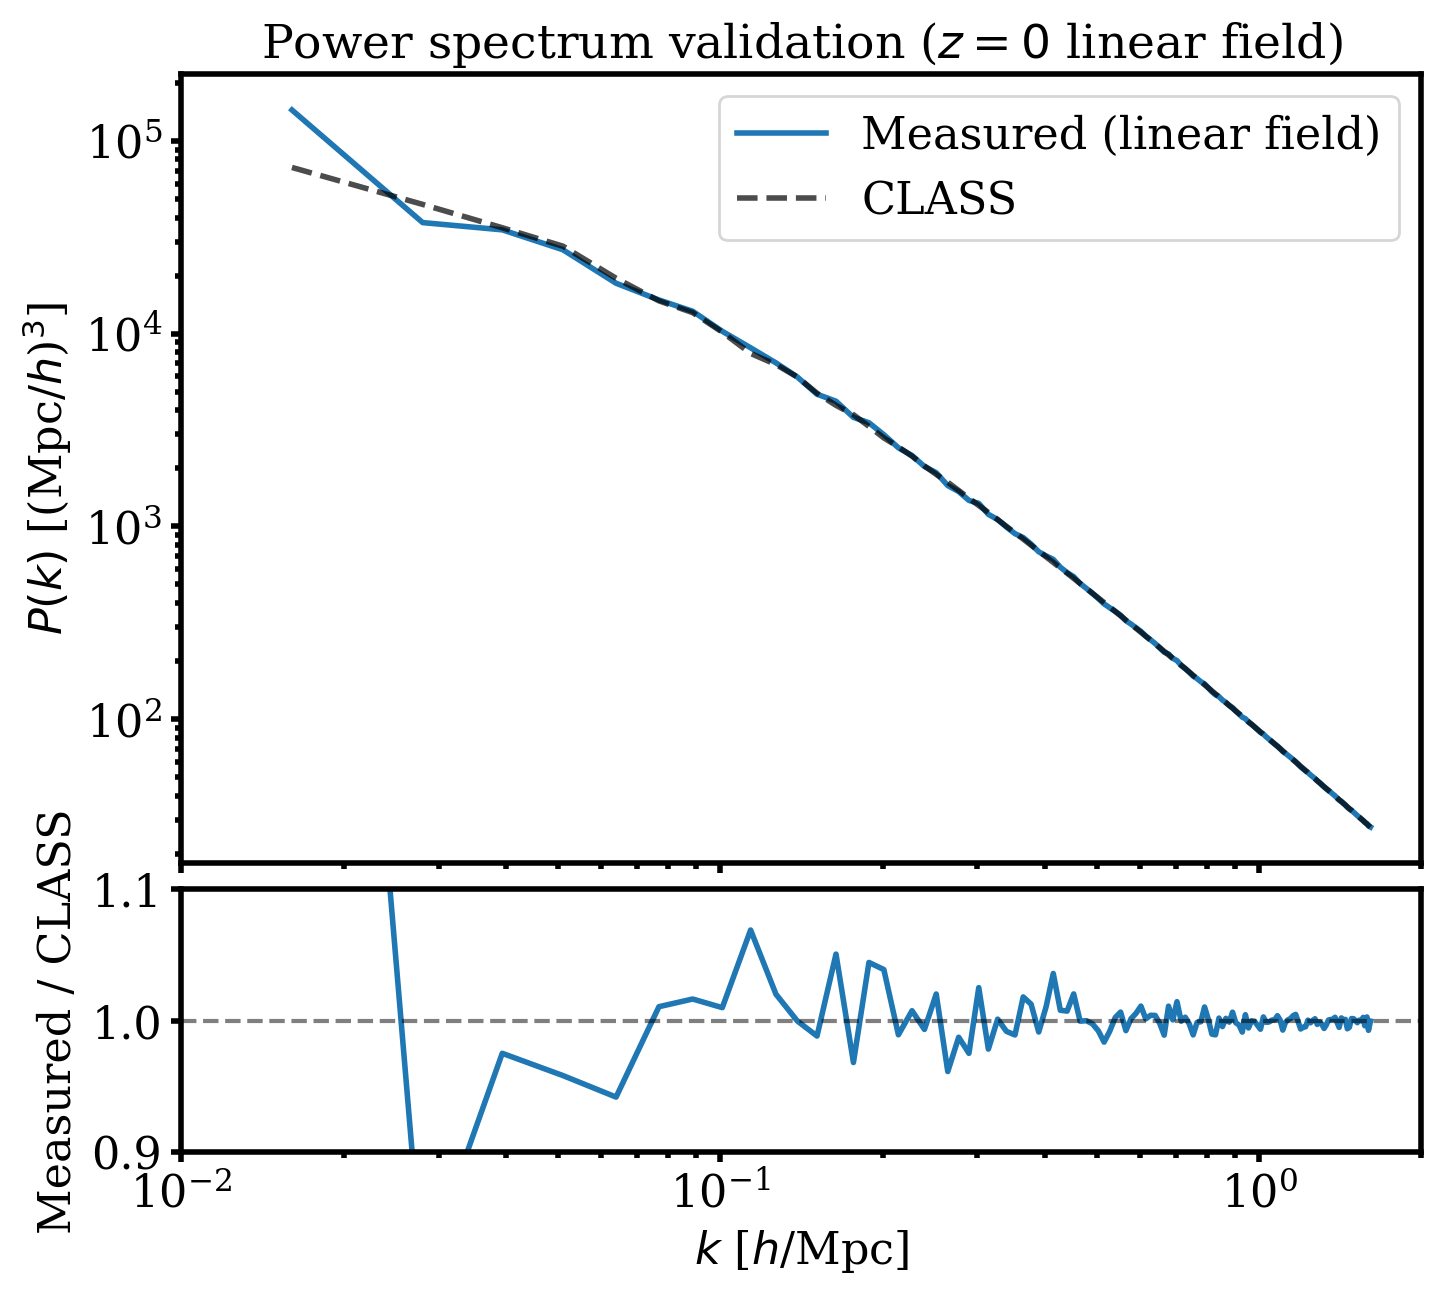

In [41]:
# Precompute the k-grid for this box (used by all P(k) measurements)
kgrid = make_k_grid(Ng, L)

# Measure P(k) from the z=0 linear density field (D_+(1) = 1 for EdS)
k_meas, pk_ic, counts_ic = measure_pk(delta0_z0, kgrid)

# CLASS at z=0
pk_class_ic = p_k(np.array(k_meas))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

ax1.loglog(k_meas, pk_ic, 'C0-', lw=2, label='Measured (linear field)')
ax1.loglog(k_meas, pk_class_ic, 'k--', lw=2, alpha=0.7, label='CLASS')
ax1.set_ylabel(r'$P(k)$ [(Mpc/$h$)$^3$]')
ax1.set_xlim(0.01, 2)
ax1.legend()
ax1.set_xticklabels([])
ax1.set_title('Power spectrum validation ($z = 0$ linear field)')

ratio_ic = np.array(pk_ic) / pk_class_ic
ax2.semilogx(k_meas, ratio_ic, 'C0-', lw=2)
ax2.axhline(1.0, color='k', ls='--', alpha=0.5)
ax2.set_xlabel(r'$k$ [$h$/Mpc]')
ax2.set_ylabel('Measured / CLASS')
ax2.set_xlim(0.01, 2)
ax2.set_ylim(0.9, 1.1)

plt.show()

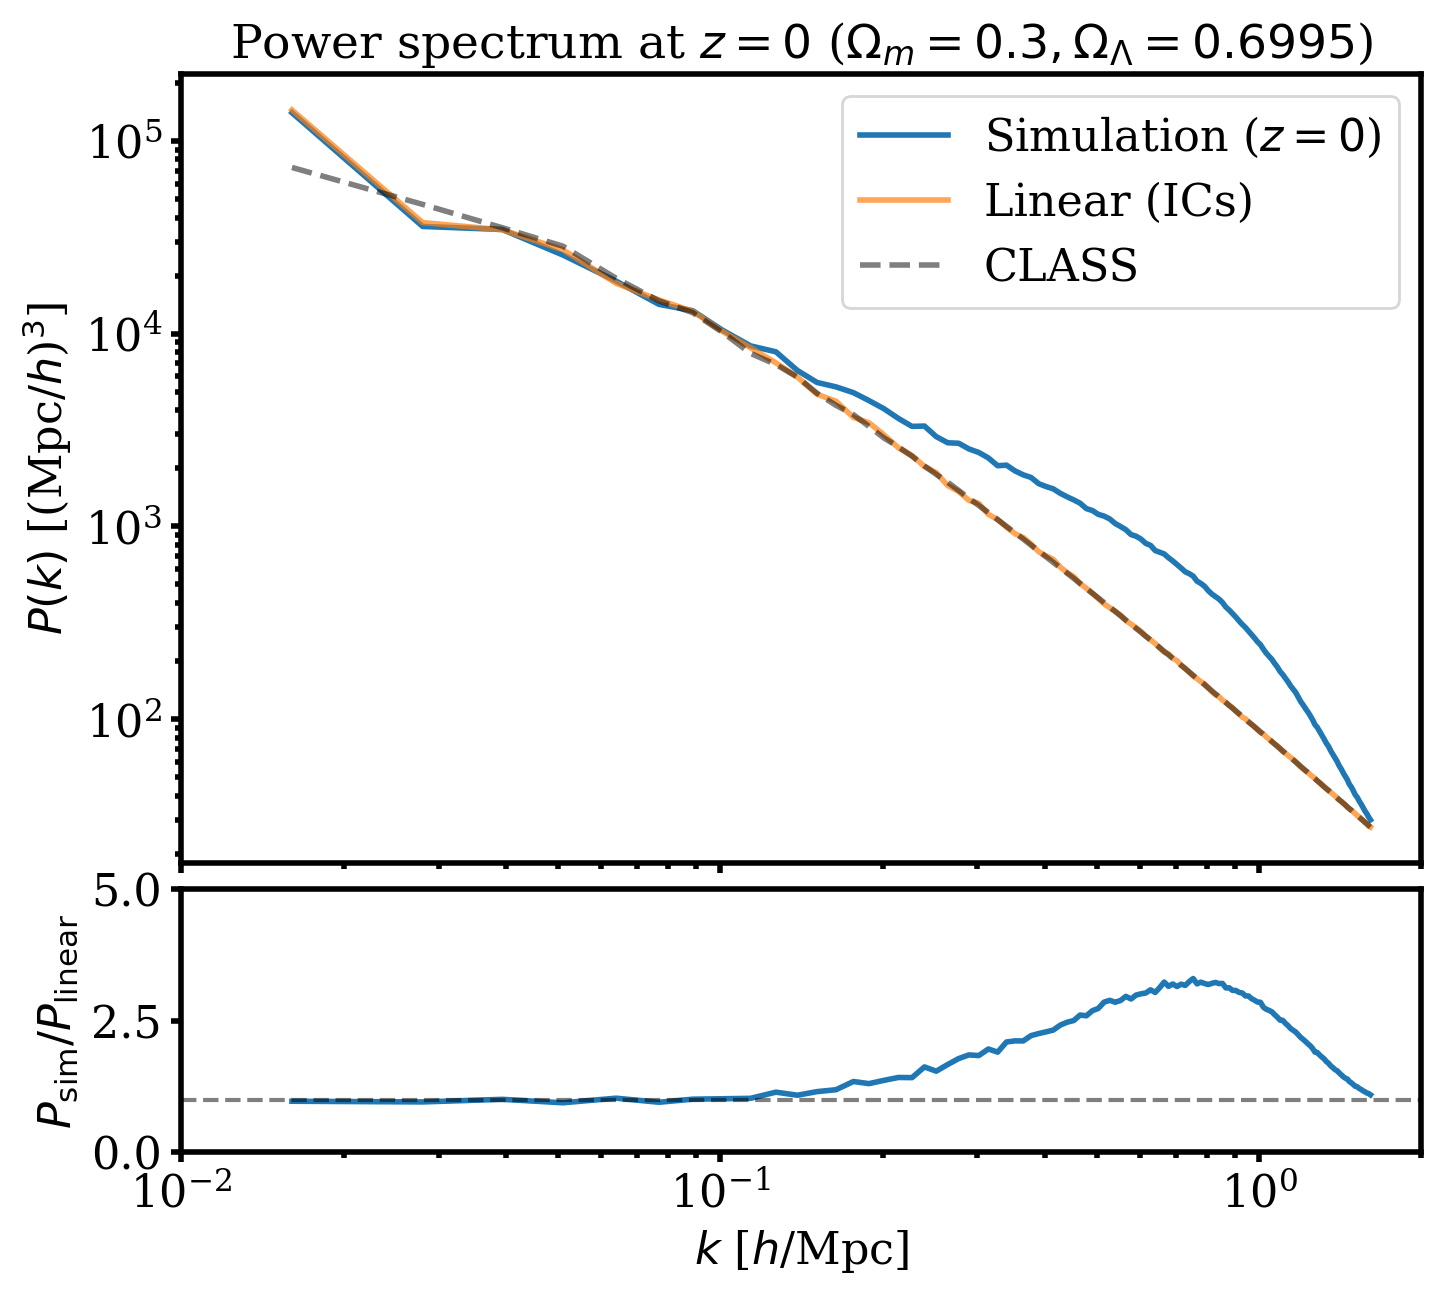

In [42]:
# Linear prediction: delta_0 is already the z=0 field (D_+(1) = 1 for EdS)
delta_linear = delta0_z0

# Nonlinear: CIC deposit of z=0 particles
delta_sim = deposit_to_delta(snapshots[0]['pos'], Ng, L)

# Measure P(k) from z=0 simulation
k_meas, pk_z0, counts_z0 = measure_pk(delta_sim, kgrid)

# CLASS P(k) at z=0
pk_class_z0 = p_k(np.array(k_meas))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

ax1.loglog(k_meas, pk_z0, 'C0-', lw=2, label='Simulation ($z = 0$)')
ax1.loglog(k_meas, pk_ic, 'C1-', lw=2, alpha=0.7, label='Linear (ICs)')
ax1.loglog(k_meas, pk_class_z0, 'k--', lw=2, alpha=0.5, label='CLASS')
ax1.set_ylabel(r'$P(k)$ [(Mpc/$h$)$^3$]')
ax1.set_xlim(0.01, 2)
ax1.legend()
ax1.set_xticklabels([])
ax1.set_title(f'Power spectrum at $z = 0$ ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$)')

ratio_z0 = np.array(pk_z0) / np.array(pk_ic)
ax2.semilogx(k_meas, ratio_z0, 'C0-', lw=2)
ax2.axhline(1.0, color='k', ls='--', alpha=0.5)
ax2.set_xlabel(r'$k$ [$h$/Mpc]')
ax2.set_ylabel(r'$P_\mathrm{sim} / P_\mathrm{linear}$')
ax2.set_xlim(0.01, 2)
ax2.set_ylim(0, 5)
plt.savefig(f"nonlin_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()

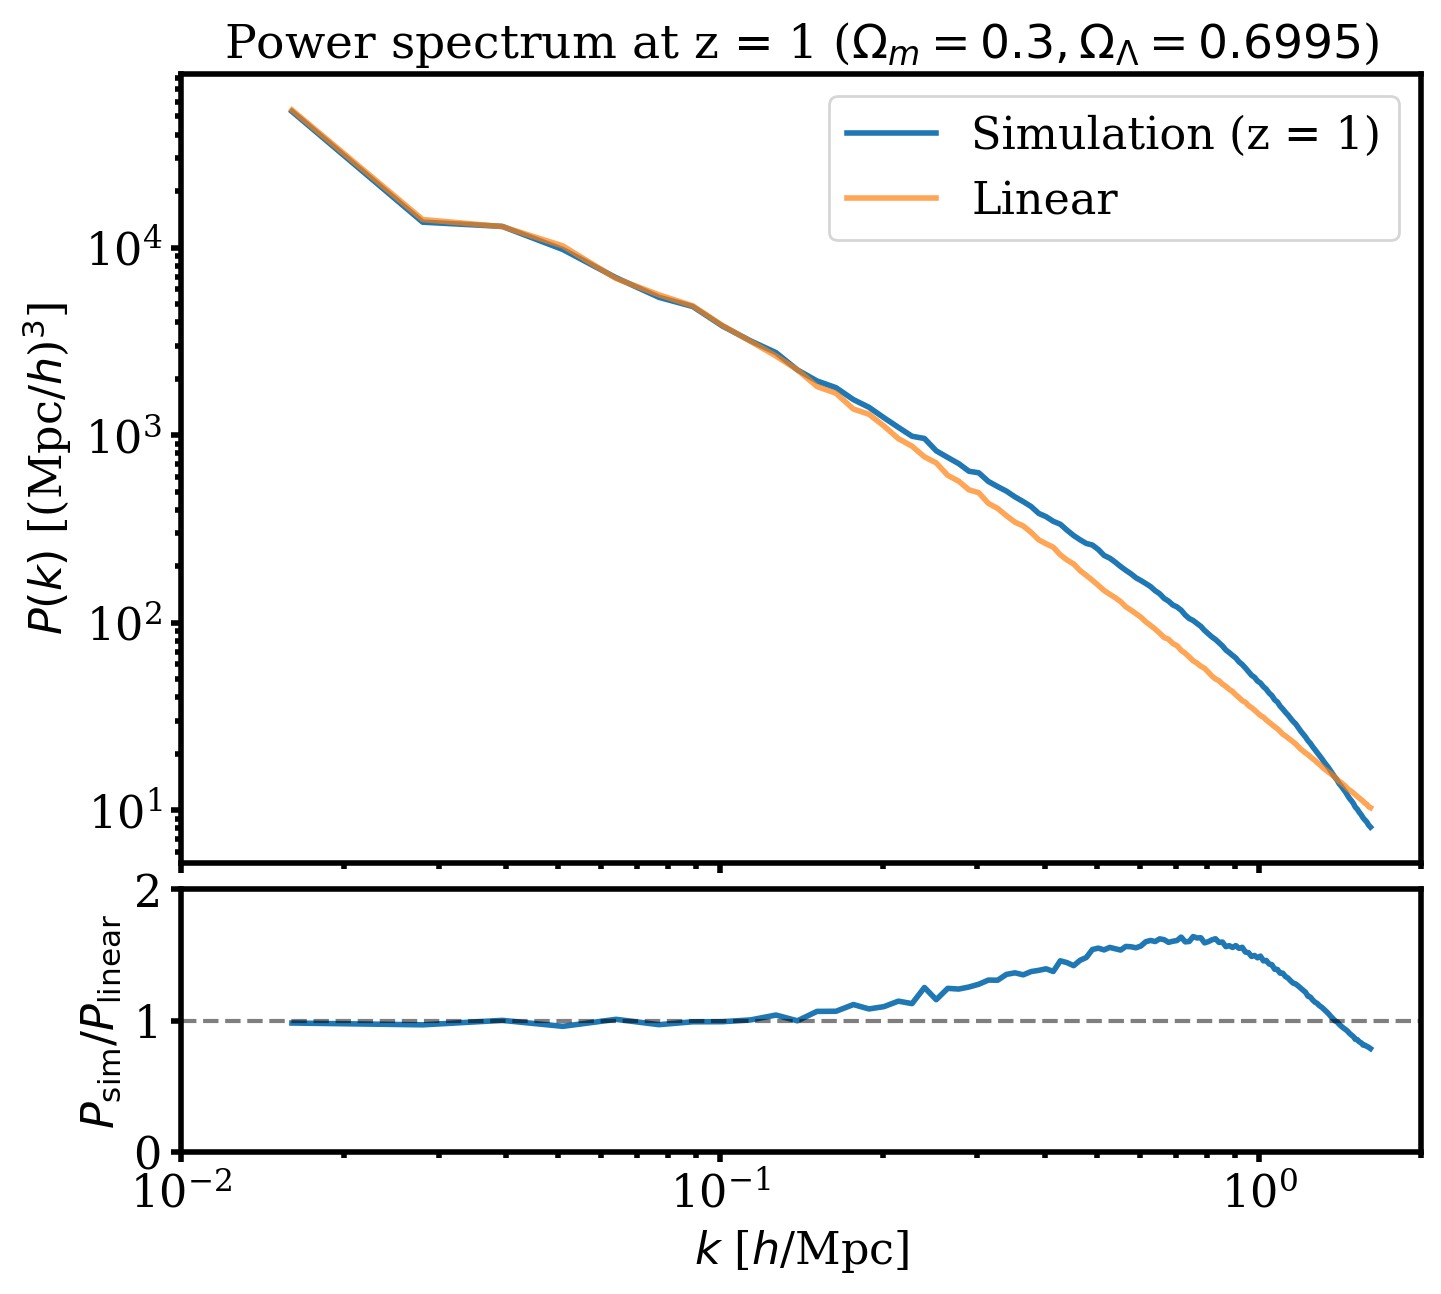

In [48]:
# Set target snapshot redshift and scale factor
z_target = 1
a_target = 1.0 / (1.0 + z_target)

new_cosmo = create_cosmo_instance(
    h=0.7,
    omega_b=0.02237,
    omega_cdm=0.12463,
    max_z=1.0
)

delta_sim_z1 = deposit_to_delta(snapshots[z_target]['pos'], Ng, L)

# Measure P(k) from z=1 simulation
k_meas, pk_z1, counts_z1 = measure_pk(delta_sim_z1, kgrid)
# pk_class_z1 = pk_of_k(np.array(k_meas), cosmo=new_cosmo, z=z_target)

growth_ratio = D_plus(a_target, params) / D_plus(1.0, params)
pk_linear_z1 = np.array(pk_ic) * growth_ratio ** 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

ax1.loglog(k_meas, pk_z1, 'C0-', lw=2, label=f'Simulation (z = {z_target})')
ax1.loglog(k_meas, pk_linear_z1, 'C1-', lw=2, alpha=0.7, label='Linear')
# ax1.loglog(k_meas, pk_class_z1, 'k--', lw=2, alpha=0.5, label='CLASS')

ax1.set_ylabel(r'$P(k)$ [(Mpc/$h$)$^3$]')
ax1.set_xlim(0.01, 2)
ax1.legend()
ax1.set_xticklabels([])
ax1.set_title(f'Power spectrum at z = {z_target} ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$)')

# Update the ratio to use the new z=1 arrays
ratio_z1 = np.array(pk_z1) / pk_linear_z1
ax2.semilogx(k_meas, ratio_z1, 'C0-', lw=2)
ax2.axhline(1.0, color='k', ls='--', alpha=0.5)
ax2.set_xlabel(r'$k$ [$h$/Mpc]')
ax2.set_ylabel(r'$P_\mathrm{sim} / P_\mathrm{linear}$')
ax2.set_xlim(0.01, 2)
ax2.set_ylim(0, 2)
plt.savefig(f"nonlin_z{z_target}_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()

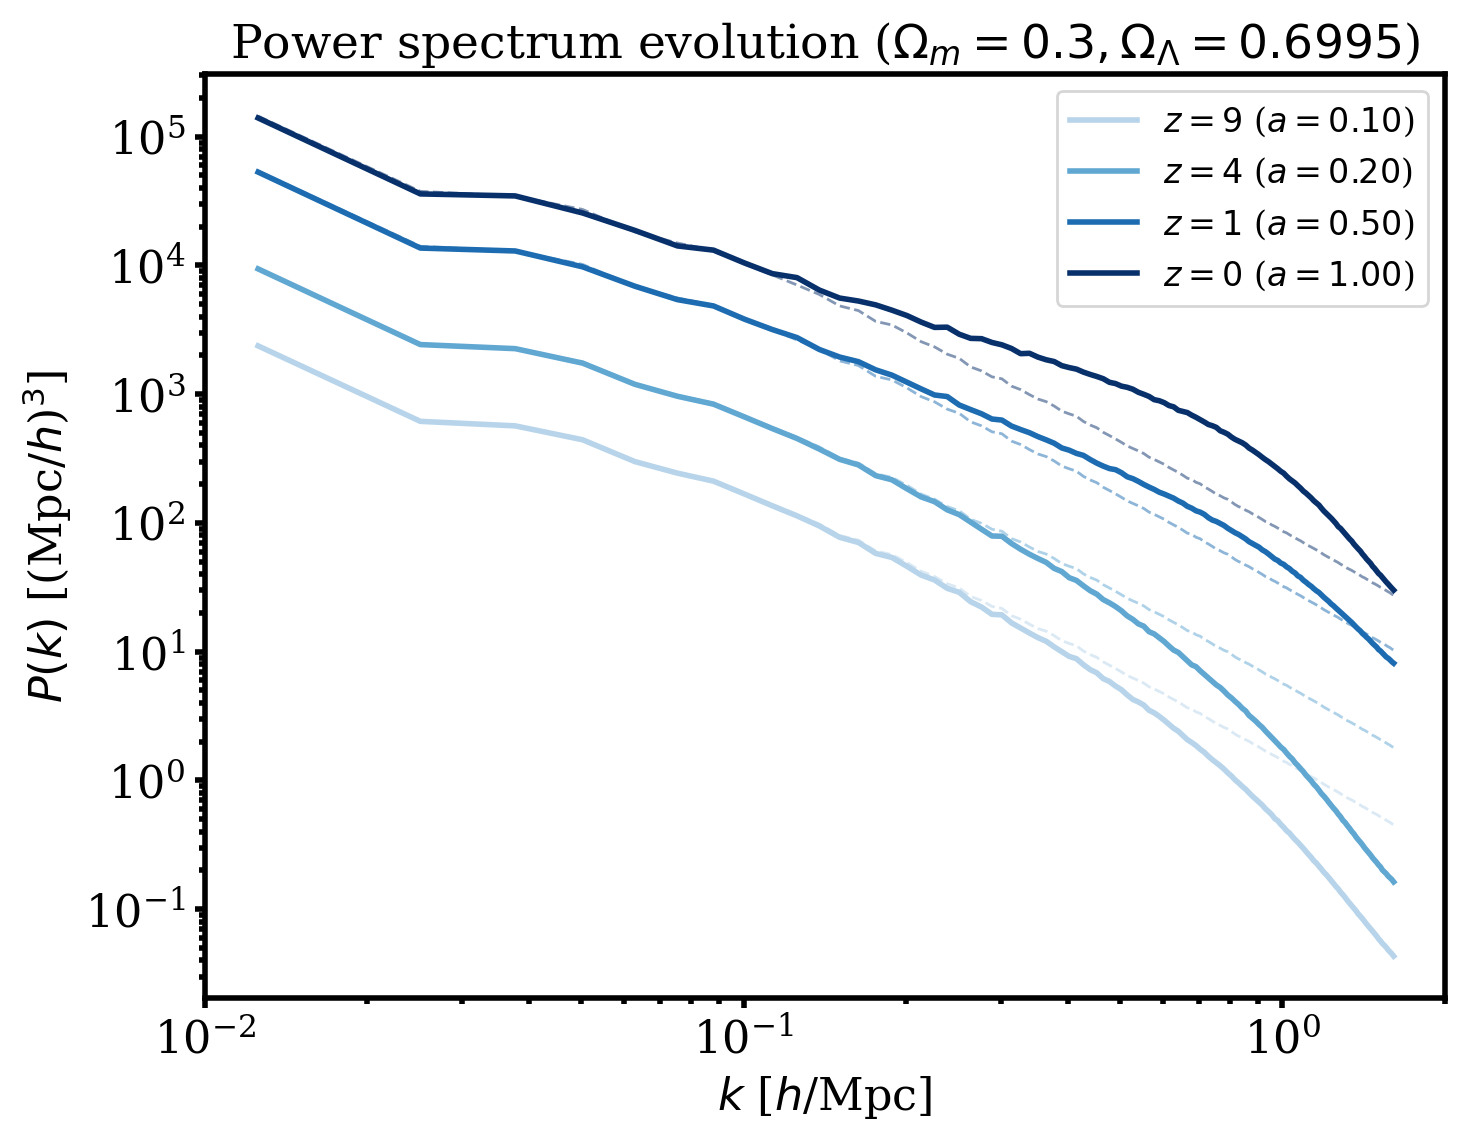

In [47]:
# Measure P(k) at each snapshot
pk_snapshots = {}
for z_snap in z_snapshots:
    delta_snap = deposit_to_delta(snapshots[z_snap]['pos'], Ng, L)
    _, pk_snap, _ = measure_pk(delta_snap, kgrid)
    pk_snapshots[z_snap] = pk_snap

# P(k) at the initial conditions (reference)
_, pk_init, _ = measure_pk(deposit_to_delta(pos_ic, Ng, L), kgrid)

k_centers = np.array(kgrid['k_centers'])

fig, ax = plt.subplots(figsize=(8, 6))

# Snapshots with increasing darkness, plus scaled IC prediction
colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(z_snapshots)))
for i, z_snap in enumerate(z_snapshots):
    a_snap = snapshots[z_snap]['a']
    # Scaled IC: P(k, a) = P_IC(k) * D+(a)^2
    growth_ratio = D_plus(a_snap, params) / D_plus(1.0, params)
    pk_scaled_ic = np.array(pk_ic) * growth_ratio ** 2
    ax.loglog(k_centers, pk_scaled_ic, color=colors[i], lw=1, ls='--', alpha=0.5)
    ax.loglog(k_centers, pk_snapshots[z_snap], color=colors[i], lw=2,
              label=f'$z = {z_snap}$ ($a = {a_snap:.2f}$)')

ax.set_xlabel(r'$k$ [$h$/Mpc]')
ax.set_ylabel(r'$P(k)$ [(Mpc/$h$)$^3$]')
ax.set_xlim(0.01, 2)
ax.legend(fontsize=12)
ax.set_title(f'Power spectrum evolution ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$)')
plt.savefig(f"power_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()

In linear theory, all Fourer modes grow at the same rate: $P(k, a) = D_+(a)^2P(k, a_\text{init})/D_+(a_\text{init})^2$. For EdS, $D_+(a) = a$. However, in general, we have that
$$D_+(a) = \frac{5\Omega_mH(a)}{2}\int_0^a\frac{da'}{(a'H(a'))^3}$$

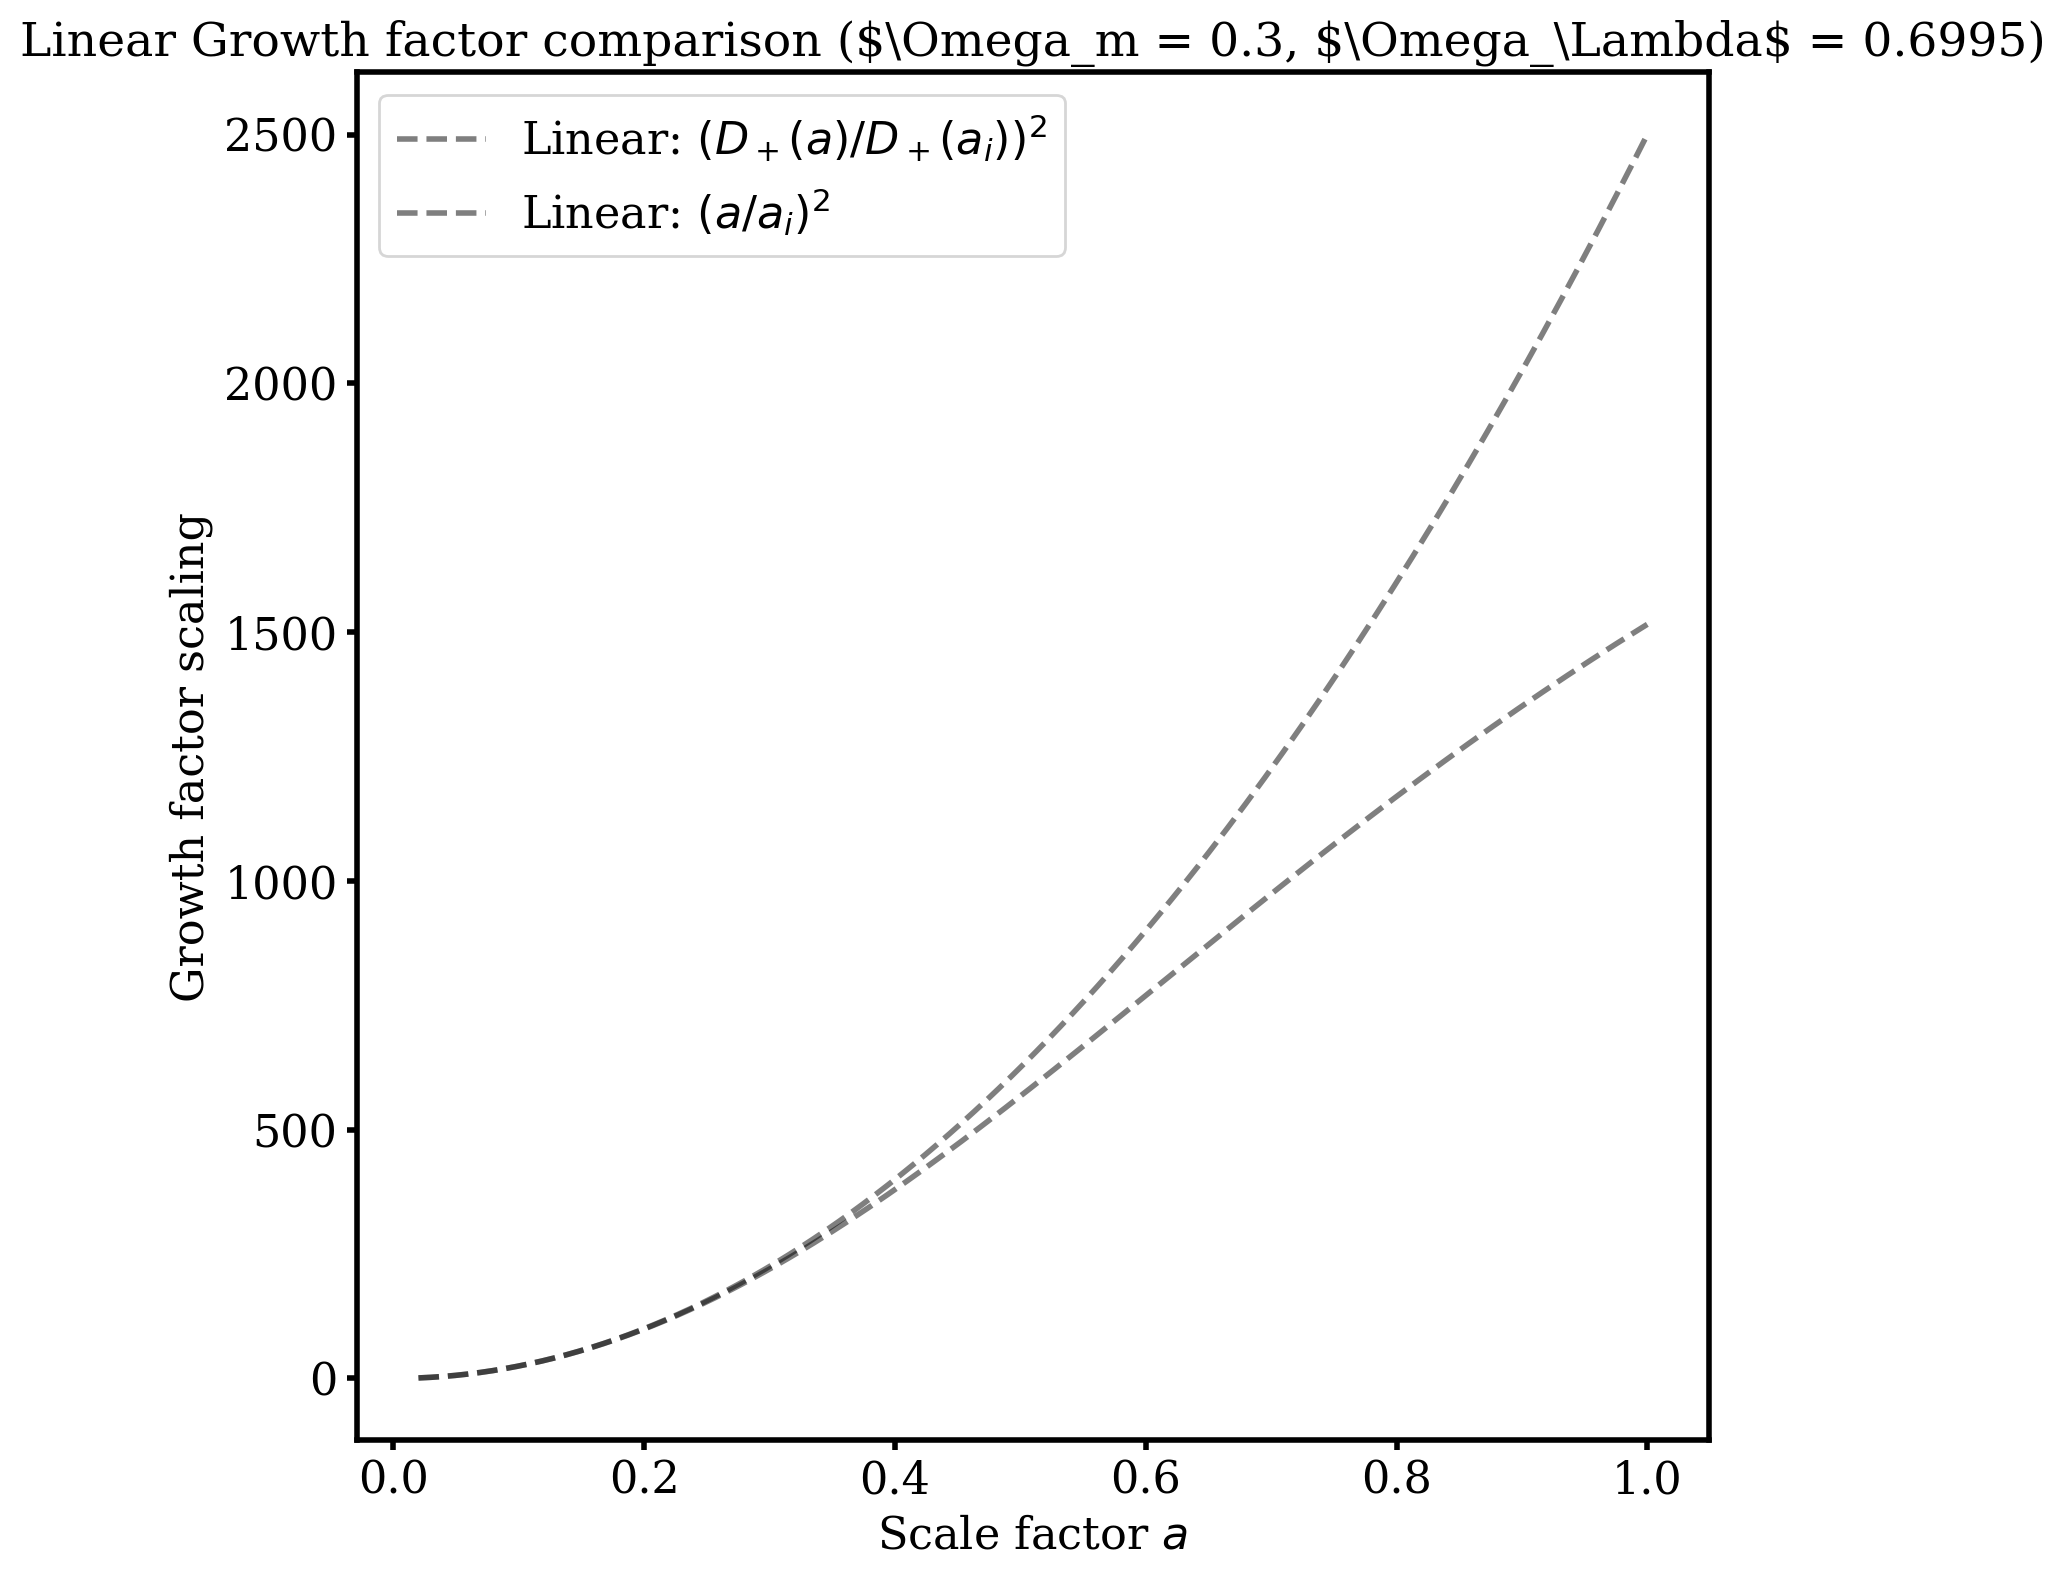

In [44]:
# Why is (a/a_init)^2 not a perfect match? Nonlinear growth and mode coupling cause deviations from the simple linear scaling, especially at late times and smaller scales (higher k). The initial conditions are perfectly linear, but as structures form, the growth becomes nonlinear, leading to an excess of power compared to the linear prediction.
a_theory =  np.linspace(a_init, 1.0, 200)
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(a_theory, (D_plus(a_theory, params) / D_plus(a_init, params))**2, 'k--', lw=2, alpha=0.5,
        label=r'Linear: $(D_+(a)/D_+(a_i))^2$')
ax.plot(a_theory, (a_theory / a_init)**2, 'k--', lw=2, alpha=0.5,
        label=r'Linear: $(a/a_i)^2$')
ax.set_xlabel('Scale factor $a$')
ax.set_ylabel('Growth factor scaling')
ax.legend()
ax.set_title(f'Linear Growth factor comparison ($\Omega_m = {params.Omega_m}, $\Omega_\Lambda$ = {params.Omega_Lambda})')
plt.tight_layout()
plt.show()

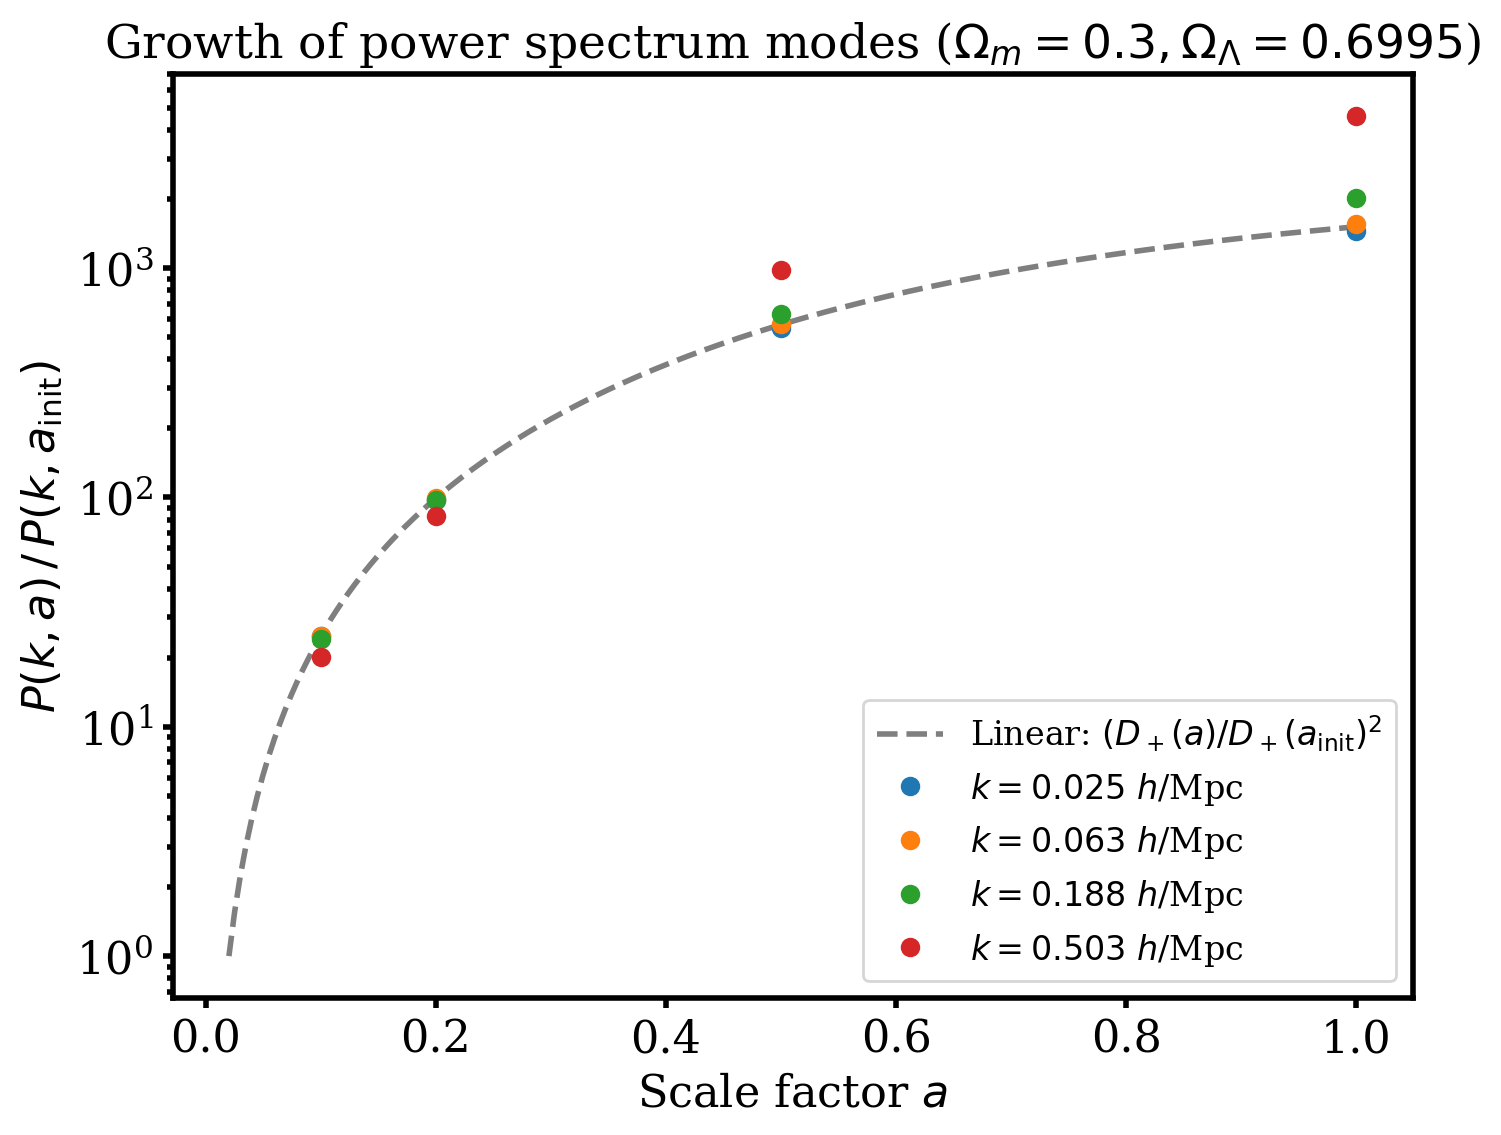

In [45]:
k_fund = 2 * np.pi / L
k_targets = [2 * k_fund, 5 * k_fund, 15 * k_fund, 40 * k_fund]

fig, ax = plt.subplots(figsize=(8, 6))

# EdS prediction: (a / a_init)^2
a_theory = np.linspace(a_init, 1.0, 200)

ax.plot(a_theory, (D_plus(a_theory, params) / D_plus(a_init, params))**2, 'k--', lw=2, alpha=0.5,
        label=r'Linear: $(D_+(a)/D_+(a_\text{init})^2$')

for ik_target, k_target in enumerate(k_targets):
    idx_k = np.argmin(np.abs(k_centers - k_target))
    k_actual = k_centers[idx_k]
    pk_ref = float(pk_init[idx_k])

    a_vals = []
    growth_vals = []
    for z_snap in z_snapshots:
        a_snap = snapshots[z_snap]['a']
        a_vals.append(a_snap)
        growth_vals.append(float(pk_snapshots[z_snap][idx_k]) / pk_ref)

    ax.plot(a_vals, growth_vals, 'o', color=f'C{ik_target}',
            label=f'$k = {k_actual:.3f}$ $h$/Mpc', ms=6)

ax.set_xlabel('Scale factor $a$')
ax.set_ylabel(r'$P(k, a) \,/\, P(k, a_\mathrm{init})$')
ax.set_title(f'Growth of power spectrum modes ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$)')
ax.set_yscale('log')
ax.legend(fontsize=12)
plt.savefig(f"growth_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()

Now we wish to track the divergence of the velocity at large scales. Recall that $\mathbf{p} = ma^2 \dot{\mathbf{x}}$ or in other words $\mathbf{p} = ma\mathbf{v}_\text{pec}$. If we set $m_p = 1$ per our code unit convention we get exactly that
$$\mathbf{v}_\text{pec} = \frac{\mathbf{p}}{a}$$
which we use when we calculate the divergence $\theta(\mathbf{x}) = \nabla \cdot \mathbf{p}$.

Now, we recall from Lecture 17 that we should expect the linear theory divergence to be
$$\nabla \cdot \mathbf{v} = aH\delta \frac{d\ln D}{d\ln a}$$, where $$f = \frac{d\ln D}{d\ln a}$$, which we set to 1 in this case. Therefore we should expect that
$$\nabla \cdot \mathbf{v}_\text{pec} = aH\delta$$
which is the subject that we wish to aanlyze.

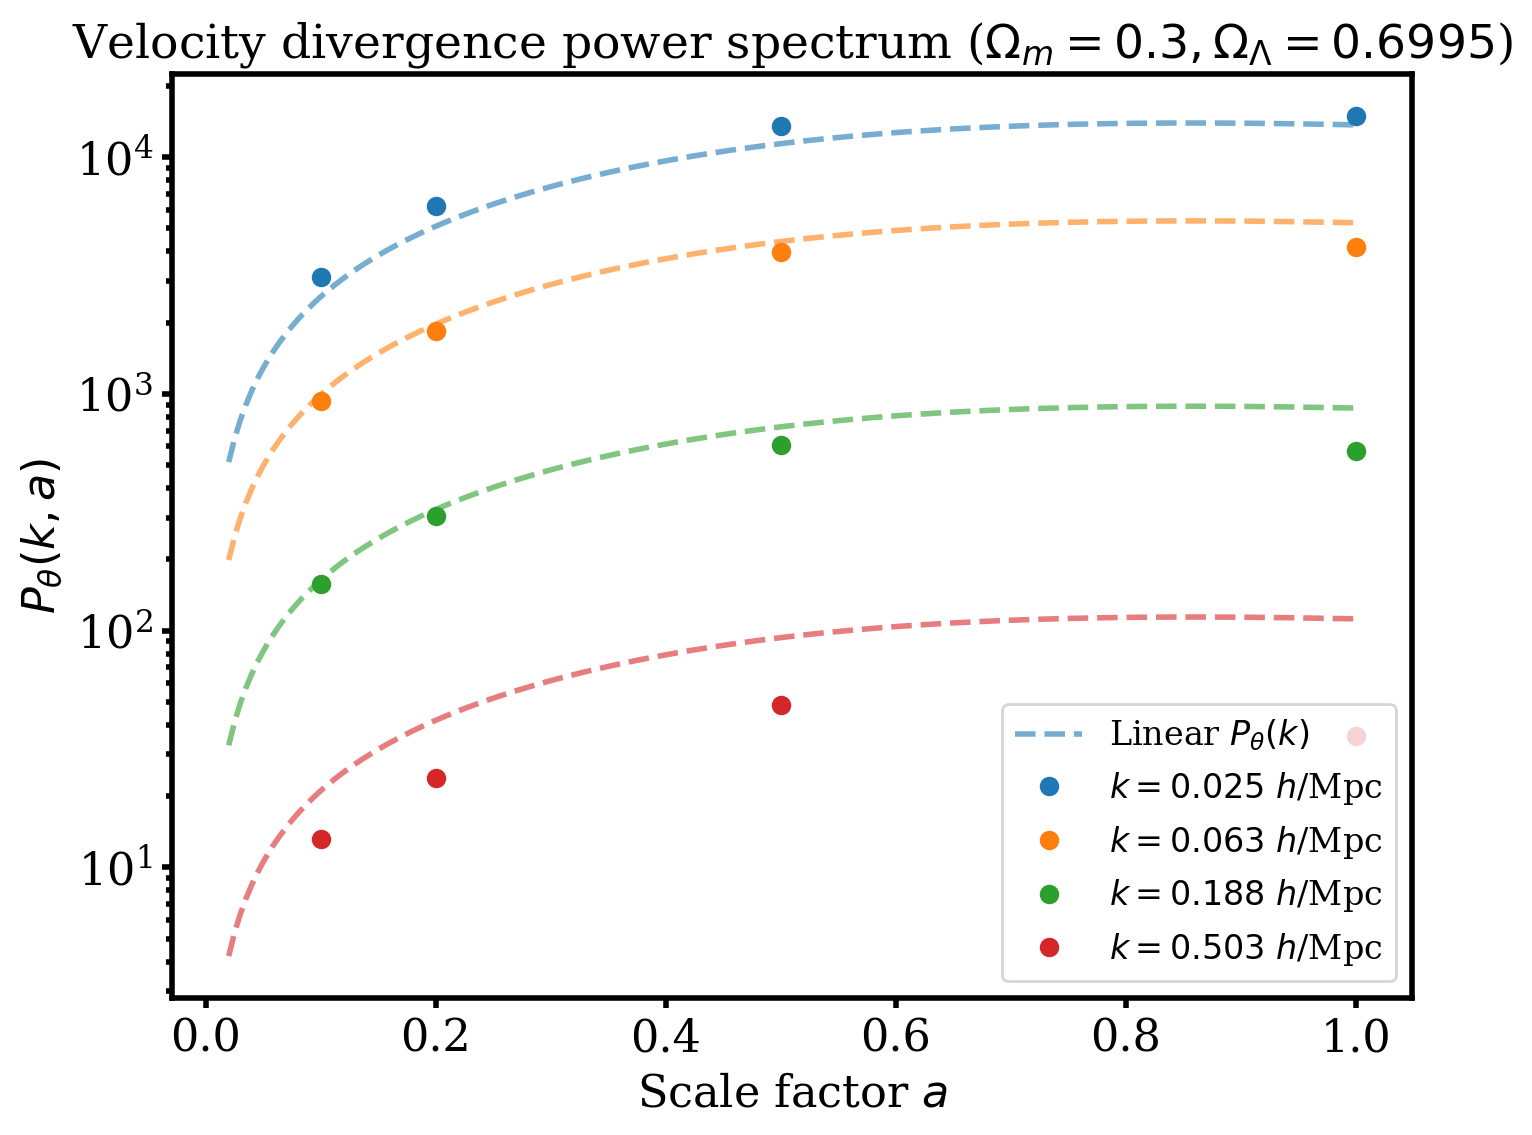

In [46]:
# Calculate nabla * v_code = -f delta
# where f = dlnD+/dln a is the growth rate (f=1 for EdS)

def linear_theory_theta(a, k, params, a_init=0.01):
    """Linear theory prediction for velocity divergence power spectrum (Code Units)."""
    
    # 1. Calculate growth factors
    D_a = D_plus(a, params)
    D_today = D_plus(1.0, params)  # Normalize against today, not a_init!
    
    # 2. Differentiate D+ to get the growth rate f(a)
    dlnD_dln_a = jnp.gradient(jnp.log(D_a), jnp.log(a))
    f_a = dlnD_dln_a 

    # 3. Calculate the power spectrum
    # - Restore (f_a * a * H)**2 to match the comoving velocity divergence measured in code
    # - Scale back from today's power spectrum using (D_a / D_today)**2
    pk_theta = (f_a * a * H(a, params))**2 * pk_of_k(k, cosmo) * (D_a / D_today)**2
    
    return pk_theta

fig, ax = plt.subplots(figsize=(8, 6))

a_vals = []
theta_pk_vals = []
for z_snap in z_snapshots:
    a_snap = snapshots[z_snap]['a']
    a_vals.append(a_snap)

    pos_s = snapshots[z_snap]['pos']
    mom_s = snapshots[z_snap]['mom']
    
    # Calculate divergence directly in code units
    theta_s = compute_velocity_divergence(pos_s, mom_s, a_snap, Ng, L)
    k_theta, pk_theta_s, _ = measure_pk(theta_s, kgrid)
    
    k_theta_cpu = np.asarray(k_theta)
    pk_theta_s_cpu = np.asarray(pk_theta_s)
    
    pk_theta_interp = interp1d(k_theta_cpu, pk_theta_s_cpu, bounds_error=False, fill_value="extrapolate")
    pk_theta_vals_at_targets = pk_theta_interp(k_targets)
    theta_pk_vals.append(pk_theta_vals_at_targets)

theta_pk_vals = np.array(theta_pk_vals)

# Tie the plotting together in a single loop
for ik_target, k_target in enumerate(k_targets):
    theory_label = r'Linear $P_{\theta}(k)$' if ik_target == 0 else None
    ax.plot(a_theory, linear_theory_theta(a_theory, k_target, params), '--', 
            color=f'C{ik_target}', lw=2, alpha=0.6, label=theory_label)
    ax.plot(a_vals, theta_pk_vals[:, ik_target], 'o', color=f'C{ik_target}',
            label=f'$k = {k_target:.3f}$ $h$/Mpc')
    
ax.set_xlabel('Scale factor $a$')
ax.set_ylabel(r'$P_{\theta}(k, a)$')
ax.set_title(f'Velocity divergence power spectrum ($\Omega_m = {params.Omega_m}, \Omega_\Lambda = {params.Omega_Lambda}$)')
ax.set_yscale('log')
ax.legend(fontsize=12)
plt.savefig(f"div_{params.Omega_m}_{params.Omega_Lambda}.png", dpi=300)
plt.show()